# **Instanciando o dataset**




Baixando o dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("oktayrdeki/heart-disease")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease' dataset.
Path to dataset files: /kaggle/input/heart-disease


Abrindo o dataset e exibindo o 13 primeiro itens para uma breve analise de suas features


In [4]:
#Iniciando bibliotecas
import pandas as pd
import numpy as np

#Abrindo o dataset e exibindo as 5 primeiras linhas
leitura = pd.read_csv("/kaggle/input/heart-disease/heart_disease.csv")
leitura.head(13)

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
5,25.0,Male,152.0,257.0,Low,Yes,No,No,28.144681,No,...,No,Low,Medium,5.504876,Low,126.0,91.0,4.297575,10.815983,No
6,78.0,Female,121.0,175.0,High,Yes,Yes,Yes,18.042332,No,...,No,Medium,Medium,9.240911,Medium,107.0,85.0,11.582983,19.659461,No
7,38.0,Female,161.0,187.0,Low,Yes,Yes,Yes,34.736683,No,...,No,Low,Medium,7.841008,High,228.0,111.0,4.929381,17.146599,No
8,56.0,Female,135.0,291.0,Low,No,Yes,Yes,34.493112,Yes,...,Yes,High,Low,6.941403,High,317.0,103.0,5.119015,6.051129,No
9,75.0,Male,144.0,252.0,Low,Yes,Yes,No,30.142149,No,...,Yes,Low,Medium,4.002662,High,199.0,96.0,10.005698,7.604357,No


# **Tratando variáveis categóricas**

Indentificando quantas variáveis categóricas existem no dataset

In [5]:
leitura.describe(include=np.dtype(object))

,Gender,Exercise Habits,Smoking,Family Heart Disease,Diabetes,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sugar Consumption,Heart Disease Status
count,9981,9975,9975,9979,9970,9974,9975,9974,7414,9978,9970,10000
unique,2,3,2,2,2,2,2,2,3,3,3,2
top,Male,High,Yes,No,No,Yes,Yes,No,Medium,Medium,Low,No
freq,5003,3372,5123,5004,5018,5022,5000,5036,2500,3387,3390,8000


Tratando o genero de Male = 0 e Female = 1

In [6]:
# Lista com as colunas para tratar
coluna = ["Gender"]

# Dicionário de mapeamento
mapeamento = {"Male": 0, "Female": 1}

# Aplica a substituição em todas as colunas
leitura[coluna] = leitura[coluna].replace(mapeamento)
#leitura["Gender"].describe()


/tmp/ipykernel_2189/2895322350.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  leitura[coluna] = leitura[coluna].replace(mapeamento)


Tratando colunas com High = 3, Medium = 2 e Low = 1

In [7]:
colunas = ["Exercise Habits", "Alcohol Consumption", "Stress Level", "Sugar Consumption"]

mapeamento = {"High": 3, "Medium": 2, "Low": 1}

leitura[colunas] = leitura[colunas].replace(mapeamento)
#leitura["Stress Level"].describe()


/tmp/ipykernel_2189/485476284.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  leitura[colunas] = leitura[colunas].replace(mapeamento)


Tratando as colunas com Yes = 1 e No = 0


In [8]:
# Lista com as colunas para tratar
colunas = ["Smoking", "Family Heart Disease", "Diabetes","Heart Disease Status",
           "High LDL Cholesterol", "Low HDL Cholesterol","High Blood Pressure"]

# Dicionário de mapeamento
mapeamento = {"Yes": 1, "No": 0}

# Aplica a substituição em todas as colunas
leitura[colunas] = leitura[colunas].replace(mapeamento)
#leitura["Diabetes"].describe()

/tmp/ipykernel_2189/482324734.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  leitura[colunas] = leitura[colunas].replace(mapeamento)


# **Preenchendo dados vazios**

Indentificando dados nulos para serem preenchidos futuramente

In [9]:
leitura.isnull().sum()

,0
Age,29
Gender,19
Blood Pressure,19
Cholesterol Level,30
Exercise Habits,25
Smoking,25
Family Heart Disease,21
Diabetes,30
BMI,22
High Blood Pressure,26


+ Exibindo o dataset para conferir os valores nulos

In [10]:
leitura.head(12)

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,0.0,153.0,155.0,3.0,1.0,1.0,0.0,24.991591,1.0,...,0.0,3.0,2.0,7.633228,2.0,342.0,NaN,12.969246,12.387250,0
1,69.0,1.0,146.0,286.0,3.0,0.0,1.0,1.0,25.221799,0.0,...,0.0,2.0,3.0,8.744034,2.0,133.0,157.0,9.355389,19.298875,0
2,46.0,0.0,126.0,216.0,1.0,0.0,0.0,0.0,29.855447,0.0,...,1.0,1.0,1.0,4.440440,1.0,393.0,92.0,12.709873,11.230926,0
3,32.0,1.0,122.0,293.0,3.0,1.0,1.0,0.0,24.130477,1.0,...,1.0,1.0,3.0,5.249405,3.0,293.0,94.0,12.509046,5.961958,0
4,60.0,0.0,166.0,242.0,1.0,1.0,1.0,1.0,20.486289,1.0,...,0.0,1.0,3.0,7.030971,3.0,263.0,154.0,10.381259,8.153887,0
5,25.0,0.0,152.0,257.0,1.0,1.0,0.0,0.0,28.144681,0.0,...,0.0,1.0,2.0,5.504876,1.0,126.0,91.0,4.297575,10.815983,0
6,78.0,1.0,121.0,175.0,3.0,1.0,1.0,1.0,18.042332,0.0,...,0.0,2.0,2.0,9.240911,2.0,107.0,85.0,11.582983,19.659461,0
7,38.0,1.0,161.0,187.0,1.0,1.0,1.0,1.0,34.736683,0.0,...,0.0,1.0,2.0,7.841008,3.0,228.0,111.0,4.929381,17.146599,0
8,56.0,1.0,135.0,291.0,1.0,0.0,1.0,1.0,34.493112,1.0,...,1.0,3.0,1.0,6.941403,3.0,317.0,103.0,5.119015,6.051129,0
9,75.0,0.0,144.0,252.0,1.0,1.0,1.0,0.0,30.142149,0.0,...,1.0,1.0,2.0,4.002662,3.0,199.0,96.0,10.005698,7.604357,0


+ Preenchendo o campo NONE com 0

In [11]:
leitura = leitura.fillna({"Alcohol Consumption":0})

+ Preenchendo os demais nulos com a moda para as variáveis com YES e NO e em seguida as variáveis com HIGH, MEDIUM e LOW com a média

In [12]:
colunas = ["Age", "Gender", "Exercise Habits",
"Smoking",
"Family Heart Disease",
"Diabetes",
"High Blood Pressure"	,
"Low HDL Cholesterol"	,
"High LDL Cholesterol",
"Alcohol Consumption"	,
"Stress Level"	,
"Sugar Consumption"		]

leitura[colunas] = leitura[colunas].fillna(leitura[colunas].mode().iloc[0])

colunas = ["Blood Pressure", "Cholesterol Level",
"BMI"	,
"Sleep Hours"	,
"Sugar Consumption"	,
"Triglyceride Level"	,
"Fasting Blood Sugar"	,
"CRP Level"	,
"Homocysteine Level"]

leitura[colunas] = leitura[colunas].fillna(leitura[colunas].mean().iloc[0])

leitura.head(10)

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,0.0,153.0,155.0,3.0,1.0,1.0,0.0,24.991591,1.0,...,0.0,3.0,2.0,7.633228,2.0,342.0,149.75774,12.969246,12.387250,0
1,69.0,1.0,146.0,286.0,3.0,0.0,1.0,1.0,25.221799,0.0,...,0.0,2.0,3.0,8.744034,2.0,133.0,157.00000,9.355389,19.298875,0
2,46.0,0.0,126.0,216.0,1.0,0.0,0.0,0.0,29.855447,0.0,...,1.0,1.0,1.0,4.440440,1.0,393.0,92.00000,12.709873,11.230926,0
3,32.0,1.0,122.0,293.0,3.0,1.0,1.0,0.0,24.130477,1.0,...,1.0,1.0,3.0,5.249405,3.0,293.0,94.00000,12.509046,5.961958,0
4,60.0,0.0,166.0,242.0,1.0,1.0,1.0,1.0,20.486289,1.0,...,0.0,1.0,3.0,7.030971,3.0,263.0,154.00000,10.381259,8.153887,0
5,25.0,0.0,152.0,257.0,1.0,1.0,0.0,0.0,28.144681,0.0,...,0.0,1.0,2.0,5.504876,1.0,126.0,91.00000,4.297575,10.815983,0
6,78.0,1.0,121.0,175.0,3.0,1.0,1.0,1.0,18.042332,0.0,...,0.0,2.0,2.0,9.240911,2.0,107.0,85.00000,11.582983,19.659461,0
7,38.0,1.0,161.0,187.0,1.0,1.0,1.0,1.0,34.736683,0.0,...,0.0,1.0,2.0,7.841008,3.0,228.0,111.00000,4.929381,17.146599,0
8,56.0,1.0,135.0,291.0,1.0,0.0,1.0,1.0,34.493112,1.0,...,1.0,3.0,1.0,6.941403,3.0,317.0,103.00000,5.119015,6.051129,0
9,75.0,0.0,144.0,252.0,1.0,1.0,1.0,0.0,30.142149,0.0,...,1.0,1.0,2.0,4.002662,3.0,199.0,96.00000,10.005698,7.604357,0


#**Analise** de **correlação**

+ Plotando gráfico

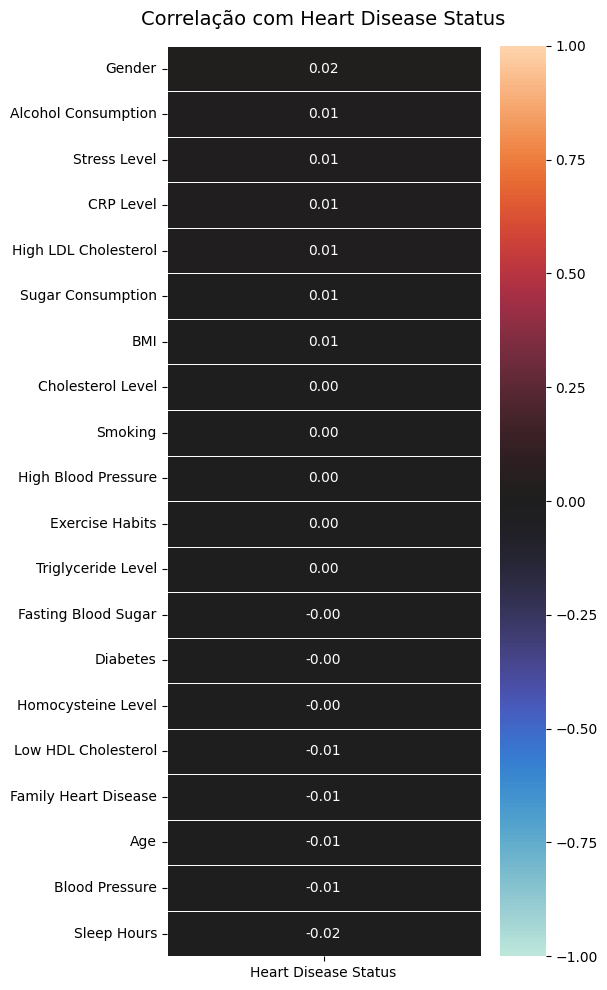

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Matriz de correlação
corr = leitura.corr(numeric_only=True)

plt.figure(figsize=(6, 10))

# Isola a coluna da variável alvo e ordena os valores
target_corr = (
    corr[["Heart Disease Status"]]
    .drop("Heart Disease Status")
    .sort_values(by="Heart Disease Status", ascending=False)
)

sns.heatmap(
    target_corr,
    annot=True,

    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f",
    linewidths=0.5,
)

plt.title("Correlação com Heart Disease Status", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

+ Nesse plot é possível observar uma anomalia. Não existe correlação relevantes entre nem um dos valores do dataset e a saida. Isso me diz que não é matemáticamente possível, utilizando esse dataset, preever com acurácia o comportamento de "Heart Status". Para confirmar esse comportamento, passamos para alguns tratamentos do dataset.


# **Tratando dataset**

+ Derrubando algumas colunas que apresentão correlação 0.

In [14]:
#Colunas a seren removidas
colunas = ["Alcohol Consumption"   ,
"Sugar Consumption"       ,
"Exercise Habits"         ,
"Stress Level"            ,
"Low HDL Cholesterol"     ,
"Smoking"                ,
"High Blood Pressure"   ,
"Family Heart Disease"   ,
"High LDL Cholesterol"    ,
"Diabetes"           ]

leitura.drop(colunas, axis=1, inplace=True)

#Salvando alterações em outro arquivo
#leitura.to_csv("/process_heart_disease.csv", index=False)



+ Adicionando colunas de índices combinados de risco na tentativa de ampliar a correlação.

In [15]:
leitura["Risk Score"] = (
    leitura["Age"] * leitura["BMI"] * leitura["Blood Pressure"]
) / 1000
leitura["Cholesterol_Ratio"] = (
    leitura["Cholesterol Level"] / (leitura["Triglyceride Level"] + 1)
)

#  **Executando os modelos**

# **KNN**

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X = leitura.drop(columns=["Heart Disease Status"])
Y = leitura.loc[:,"Heart Disease Status"]

X_train, X_teste, Y_train, Y_teste = train_test_split(X, Y)

knn = KNeighborsClassifier(n_neighbors = 20 )
knn.fit(X_train, Y_train)
y_pred = knn.predict(X_teste)
print("Precissão do KNN:", accuracy_score(Y_teste, y_pred)*100)

Precissão do KNN: 79.67999999999999


+ Para o KNN é possível observar uma constate acurácia de aproximadamente 80% independente das alterações do modelo. O que é contraditório com o que o heatmap nos revela. Segundo ele essa acurácia deveria ser baixissima. Entretanto, continuamos para o Random Forest na tentativa de entender melhor o que está contecendo.

# **Random Forest (RF)**

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

X = leitura.drop(columns=["Heart Disease Status"])
Y = leitura.loc[:, "Heart Disease Status"]

X_train, X_teste, Y_train, Y_teste = train_test_split(X, Y)

rf = RandomForestClassifier(n_estimators=100, class_weight="balanced",)
rf.fit(X_train, Y_train)

y_pred = rf.predict(X_teste)
print(
    f"Acurácia do Random Forest: {accuracy_score(Y_teste, y_pred) * 100:.2f}%"
)

Acurácia do Random Forest: 78.64%


+ Novamente é possível ver uma repetição de 80% de acurácia, o que não está certo. Os modelo se comportam de maneira diferente para suas decisões, e essa repetição de resultados entre os dois modelos é preeocupante. Logo, passamos para o descriminante do resultado do RF, a matriz de confusão.

+ Matriz de confusão

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Veja a matriz de confusão para confirmar que o modelo só chuta classe 0
print(confusion_matrix(Y_teste, y_pred))
print(classification_report(Y_teste, y_pred))

[[1600    0]
 [ 400    0]]
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1600
           1       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


+ Há matriz de confusão tem o finco de nos mostrar quantas resposta certas foi feita em cima de cada parâmetro possível, no caso da nossa classificação YES ou NO para "Heart Disease Status". Assim ao observar as resposta para o nosso modelo, vemos que TODAS as resposta escolhido foram NO, o que é bizarro. Porém, quando paramos para observar o dataset é possível ver o seguinte padrão:  

In [24]:
leitura["Heart Disease Status"].value_counts()

,count
Heart Disease Status,
0,8000
1,2000


+ Na nossa variável alvo é possível ver que existem EXATAMENTE 20% de pessoa com problema no coração e 80% estão com o coração saudável. Logo, ao trenar nosso modelo ele termina por CHUTAR TODAS AS RESPOSTAS como NO o que lhe garante 80% de acurácia. Sendo assim, a única conclusão lógica é que os dados desse dataset são ou de pessíma qualidade, ou eles foram fábricados. Por fim, isso nos impede de fazer qualquer analise e, por consequência, qualquer predição.